In [1]:
## 1. ENVIRONMENT CHECK

import pandas as pd
print("Setup successful!")

Setup successful!


In [2]:
# Define consistent colour palette for the whole project
purple_palette = ['#4B0082', '#6A5ACD', '#8A7CD6', '#9683EC', '#B19CD9', '#C8A2C8']

In [3]:
## 2. LOADING THE CORE FILES 

data3 = pd.read_excel('../data/raw/Supplementary Data 3.xlsx')
gene_reference = pd.read_excel('../data/raw/Supplementary Data 6.xlsx', sheet_name='all_gene_families')

# Quick check
print("Data 3 shape:", data3.shape)
print("Gene reference shape:", gene_reference.shape)
data3.head()

Data 3 shape: (14738, 148)
Gene reference shape: (101, 10)


,Unnamed: 0,study_name,subject_id,sample_id,body_site,country,full_country,continent,sub_region,non_westernized,...,streptogramin vat acetyltransferase,streptothricin acetyltransferase (SAT),subclass B1 Bacillus cereus Bc beta-lactamase,subclass B1 Bacteroides xylanisolvens crx beta-lactamase,sulfonamide resistant sul,tetracycline inactivation enzyme,tetracycline-resistant ribosomal protection protein,trimethoprim resistant dihydrofolate reductase dfr,undecaprenyl pyrophosphate related proteins,vga-type ABC-F protein
0,0,AsnicarF_2017,MV_FEI1,MV_FEI1_t1Q14,stool,ITA,Italy,Europe,Southern Europe,no,...,0,1,0,0,0,0,1,1,1,0
1,1,AsnicarF_2017,MV_FEI2,MV_FEI2_t1Q14,stool,ITA,Italy,Europe,Southern Europe,no,...,0,0,0,0,0,0,1,0,0,0
2,2,AsnicarF_2017,MV_FEI3,MV_FEI3_t1Q14,stool,ITA,Italy,Europe,Southern Europe,no,...,0,1,0,0,0,0,0,1,1,0
3,3,AsnicarF_2017,MV_FEI4,MV_FEI4_t1Q14,stool,ITA,Italy,Europe,Southern Europe,no,...,0,0,0,0,0,0,1,1,1,0
4,4,AsnicarF_2017,MV_FEI4,MV_FEI4_t2Q15,stool,ITA,Italy,Europe,Southern Europe,no,...,0,0,0,0,0,0,1,1,1,0


In [4]:
# Check column names
print(data3.columns.tolist()[:10])  # first 10 column names
print(gene_reference.columns.tolist())

['Unnamed: 0', 'study_name', 'subject_id', 'sample_id', 'body_site', 'country', 'full_country', 'continent', 'sub_region', 'non_westernized']
['AMR Gene Family', 'display_name', 'Resistance Mechanism', 'antibioitc_classes', 'clinical_relevance ', 'grouped_family', 'Antibioitic Types', 'mechansim_and_beta_lactams', 'Unnamed: 8', 'Unnamed: 9']


In [5]:
## 3. CLEANING COLUMN NAMES

# Strip whitespaces from all column names at once
gene_reference.columns = gene_reference.columns.str.strip()

# Fix the typos in the source file's column names
gene_reference = gene_reference.rename(columns={
    'antibioitic_classes' : 'antibiotic_classes',
    'Antibioitic Types' : 'antibiotic_types'
})

# Confirm the fix
print(gene_reference.columns.tolist())

['AMR Gene Family', 'display_name', 'Resistance Mechanism', 'antibioitc_classes', 'clinical_relevance', 'grouped_family', 'antibiotic_types', 'mechansim_and_beta_lactams', 'Unnamed: 8', 'Unnamed: 9']


In [6]:
# Check for any fully empty rows
print("Data 3 empty rows:", data3.isnull().all(axis=1).sum())
print("Gene reference empty rows:", gene_reference.isnull().all(axis=1).sum())

Data 3 empty rows: 0
Gene reference empty rows: 0


In [7]:
# Clean whitespace and fix known typos in the source data's drug class values
gene_reference['antibiotic_types'] = (
    gene_reference['antibiotic_types']
    .str.strip()
    .str.replace('\xa0', '', regex=False)
    .str.replace('colisitin', 'colistin', regex=False)
)
print(gene_reference['antibiotic_types'].unique())

<StringArray>
[                                                           'beta-lactams',
                                                         'aminoglycosides',
                                                          'aminoglycoside',
                                                            'glycopeptide',
                                    'glycopeptide resistance gene cluster',
                                                               'quinolone',
                                                                 'peptide',
                                                                'colistin',
                                                              'fosfomycin',
                                                     'phenicol antibiotic',
                                                            'tetracycline',
 'streptogramins, chloramphenicols, florfenicols, linezolids, clindamycin',
                            'Macrolides, Lincosamides and Streptogramin b'

In [8]:
## 4. INVESTIGATING THE UNNAMED COLUMNS

# Check what's in the unnamed columns
print(gene_reference[['Unnamed: 8', 'Unnamed: 9']].head(10))

  Unnamed: 8 Unnamed: 9
0        NaN        NaN
1        NaN        NaN
2        NaN        NaN
3        NaN        NaN
4        NaN        NaN
5        NaN        NaN
6        NaN        NaN
7        NaN        NaN
8        NaN        NaN
9        NaN        NaN


In [9]:
# Removing the first column from data3 as it's just the row numbers, not significant data
data3 = data3.drop(columns=['Unnamed: 0'])
print(data3.shape)
data3.head(10)

(14738, 147)


,study_name,subject_id,sample_id,body_site,country,full_country,continent,sub_region,non_westernized,16S rRNA methyltransferase (A1408),...,streptogramin vat acetyltransferase,streptothricin acetyltransferase (SAT),subclass B1 Bacillus cereus Bc beta-lactamase,subclass B1 Bacteroides xylanisolvens crx beta-lactamase,sulfonamide resistant sul,tetracycline inactivation enzyme,tetracycline-resistant ribosomal protection protein,trimethoprim resistant dihydrofolate reductase dfr,undecaprenyl pyrophosphate related proteins,vga-type ABC-F protein
0,AsnicarF_2017,MV_FEI1,MV_FEI1_t1Q14,stool,ITA,Italy,Europe,Southern Europe,no,0,...,0,1,0,0,0,0,1,1,1,0
1,AsnicarF_2017,MV_FEI2,MV_FEI2_t1Q14,stool,ITA,Italy,Europe,Southern Europe,no,0,...,0,0,0,0,0,0,1,0,0,0
2,AsnicarF_2017,MV_FEI3,MV_FEI3_t1Q14,stool,ITA,Italy,Europe,Southern Europe,no,0,...,0,1,0,0,0,0,0,1,1,0
3,AsnicarF_2017,MV_FEI4,MV_FEI4_t1Q14,stool,ITA,Italy,Europe,Southern Europe,no,0,...,0,0,0,0,0,0,1,1,1,0
4,AsnicarF_2017,MV_FEI4,MV_FEI4_t2Q15,stool,ITA,Italy,Europe,Southern Europe,no,0,...,0,0,0,0,0,0,1,1,1,0
5,AsnicarF_2017,MV_FEI5,MV_FEI5_t1Q14,stool,ITA,Italy,Europe,Southern Europe,no,0,...,0,1,0,0,0,0,1,1,0,0
6,AsnicarF_2017,MV_FEI5,MV_FEI5_t2Q14,stool,ITA,Italy,Europe,Southern Europe,no,0,...,0,0,0,0,0,0,1,0,1,0
7,AsnicarF_2017,MV_FEI5,MV_FEI5_t3Q15,stool,ITA,Italy,Europe,Southern Europe,no,0,...,0,0,0,0,0,1,1,1,0,0
8,AsnicarF_2017,MV_FEM1,MV_FEM1_t1Q14,stool,ITA,Italy,Europe,Southern Europe,no,0,...,0,0,0,0,0,1,1,0,0,0
9,AsnicarF_2017,MV_FEM2,MV_FEM2_t1Q14,stool,ITA,Italy,Europe,Southern Europe,no,0,...,0,0,0,0,0,1,1,1,1,0


In [10]:
# Confirming whether Unnamed: 8 and 9 are empty across all rows, not just the first 10
print(gene_reference['Unnamed: 8'].isnull().sum())
print(gene_reference['Unnamed: 9'].isnull().sum())
print(gene_reference.shape[0])  # total row count, for comparison


89
100
101


In [11]:
# Show only the rows where those columns actually contain data
print(gene_reference[gene_reference['Unnamed: 8'].notnull()][['AMR Gene Family', 'Unnamed: 8']])
print("---")
print(gene_reference[gene_reference['Unnamed: 9'].notnull()][['AMR Gene Family', 'Unnamed: 9']])

                         AMR Gene Family               Unnamed: 8
61                              APH(2'')  antibiotic inactivation
66                            Van ligase               vancomycin
67  glycopeptide resistance gene cluster               vancomycin
68  glycopeptide resistance gene cluster               vancomycin
69  glycopeptide resistance gene cluster               vancomycin
70  glycopeptide resistance gene cluster               vancomycin
71  glycopeptide resistance gene cluster               vancomycin
72  glycopeptide resistance gene cluster               vancomycin
73  glycopeptide resistance gene cluster               vancomycin
74  glycopeptide resistance gene cluster               vancomycin
75  glycopeptide resistance gene cluster               vancomycin
76  glycopeptide resistance gene cluster               vancomycin
---
   AMR Gene Family       Unnamed: 9
61        APH(2'')  aminoglycosides


In [12]:
# View the full row for one case, across all the columns
print(gene_reference.loc[61])
print("---")
print(gene_reference.loc[67])

AMR Gene Family                              APH(2'')
display_name                                  AAC(6')
Resistance Mechanism                         APH(2'')
antibioitc_classes                            AAC(6')
clinical_relevance                                 no
grouped_family                antibiotic inactivation
antibiotic_types                       aminoglycoside
mechansim_and_beta_lactams            aminoglycosides
Unnamed: 8                    antibiotic inactivation
Unnamed: 9                            aminoglycosides
Name: 61, dtype: str
---
AMR Gene Family               glycopeptide resistance gene cluster
display_name                                                  vanH
Resistance Mechanism                                          vanH
antibioitc_classes                    antibiotic target alteration
clinical_relevance                                             yes
grouped_family                                        glycopeptide
antibiotic_types              gly

*Data cleaning note: 
Row 63 in the original Excel file (pandas index 61, the APH(2'') gene entry) had data shifted one column to the right. The enzyme classification was missing in the expected column and appeared instead in the unnamed columns I and J. Compared against neighbouring rows with the same resistance mechanism, corrected the 'grouped_family' and 'Antibiotic Types' values manually. The two unnamed columns (I/J) were then dropped, since the additional drug-name information they contained for a separate group of rows (vancomycin/glycopeptide entries) was already captured correctly in the 'grouped_family' column.


In [ ]:

# Fixing the one messy row (pandas index 61)
gene_reference.loc[61, 'grouped_family'] = "aminoglycoside phosphotransferase"
gene_reference.loc[61, 'antibiotic_types'] = "aminoglycoside"

# The vancomycin group's classification (glycopeptide class), is already captured correctly elsewhere, so these columns are not needed
gene_reference = gene_reference.drop(columns=['Unnamed: 8', 'Unnamed: 9'])

# Checking to see if it shows corrected shape i.e. (101,8)
print(gene_reference.shape)

(101, 9)


In [14]:
## 5. GENE PREVALENCE
 
# Understanding what the values mean 
gene_columns = data3.columns[9:]  # everything after the metadata columns
print(gene_columns[:5])
print(data3[gene_columns[:5]].head(10))

Index(['16S rRNA methyltransferase (A1408)',
       '16S rRNA methyltransferase (G1405)', 'AAC(2')', 'AAC(3)', 'AAC(6')'],
      dtype='str')
   16S rRNA methyltransferase (A1408)  16S rRNA methyltransferase (G1405)  \
0                                   0                                   0   
1                                   0                                   0   
2                                   0                                   0   
3                                   0                                   0   
4                                   0                                   0   
5                                   0                                   0   
6                                   0                                   0   
7                                   0                                   0   
8                                   0                                   0   
9                                   0                                   0   

   AAC(2')

In [15]:
# Get just the gene columns (no metadata)
gene_columns = data3.columns[9:]
gene_data = data3[gene_columns]

# Calculate prevalence: what % of samples carry each gene
# .mean() on 0/1 data gives the proportion of 1s automatically
gene_prevalence = gene_data.mean().sort_values(ascending=False) * 100

# Look at the 15 most common resistance genes
print(gene_prevalence.head(15))

tetracycline-resistant ribosomal protection protein                                                                            93.567648
major facilitator superfamily (MFS) antibiotic efflux pump                                                                     92.923056
Erm 23S ribosomal RNA methyltransferase                                                                                        80.166915
trimethoprim resistant dihydrofolate reductase dfr                                                                             76.563984
CfxA beta-lactamase                                                                                                            68.353915
CblA beta-lactamase                                                                                                            52.381599
resistance-nodulation-cell division (RND) antibiotic efflux pump                                                               46.207084
lincosamide nucleotidyltransferase (LNU) 

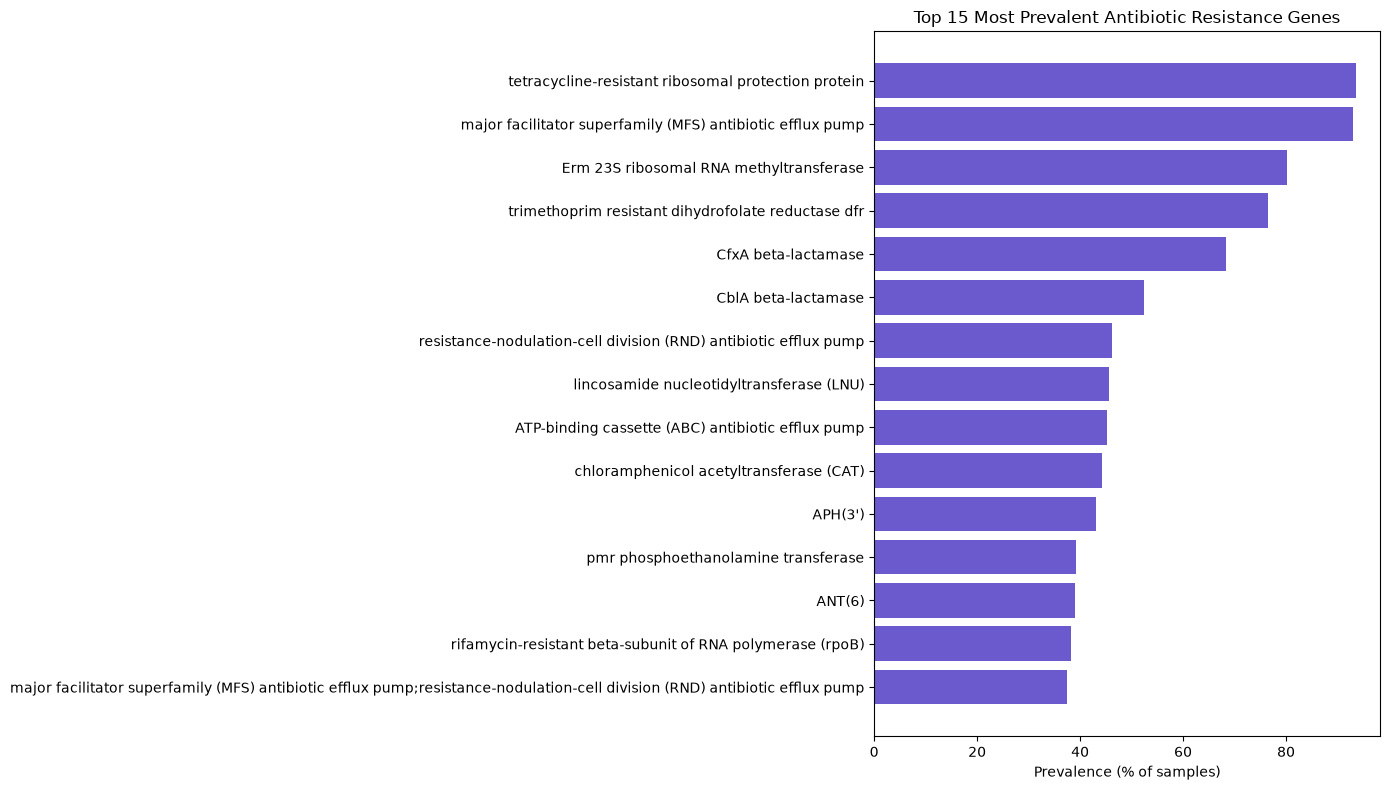

In [16]:
import matplotlib.pyplot as plt

# TOP 15 GENE PREVALENCE
top15 = gene_prevalence.head(15)

plt.figure(figsize=(14, 8))
plt.barh(top15.index, top15.values, color= '#6A5ACD')
plt.xlabel('Prevalence (% of samples)')
plt.title('Top 15 Most Prevalent Antibiotic Resistance Genes')
plt.gca().invert_yaxis()  # puts the highest value at the top instead of bottom
plt.tight_layout()  # prevents long gene names from being cut off
plt.savefig('../figures/top15_gene_prevalence.png', dpi=300, bbox_inches='tight')
plt.show()

*Interpretation:

The most prevalent individual genes - tetracycline-resistant ribosomal protection proteins (93.6%) and MFS efflux pumps (92.9%), are consistent with what is broadly reported in healthy human gut microbiomes. These mechanisms typically require low metabolic investment to maintain and are not necessarily driven by direct, recent antibiotic exposure. Tetracycline resistance, in particular, has been prevalent in intestinal commensal bacteria for several decades, potentially reflecting historical selection pressure associated with both clinical and agricultural antibiotic use. The steep decline toward rarer genes (e.g. glycopeptide resistance at 0.16%) is also expected, since glycopeptides such as vancomycin are typically reserved as last-resort clinical drugs, so widespread resistance to them would be more concerning and an unusual finding.

In [17]:
## 6. MATCHING GENES TO THE REFERENCE TABLE

# Get gene names from both tables
genes_in_data3 = set(gene_columns)
genes_in_reference = set(gene_reference['AMR Gene Family'])

In [18]:
# How many match exactly?
matching = genes_in_data3 & genes_in_reference
print(f"Genes in data3: {len(genes_in_data3)}")
print(f"Genes in reference table: {len(genes_in_reference)}")
print(f"Exact match count: {len(matching)}")

Genes in data3: 138
Genes in reference table: 89
Exact match count: 84


In [19]:
# Genes in data3 that don't have an exact match in the reference table
unmatched_in_data3 = genes_in_data3 - genes_in_reference
print(f"Unmatched from data3 ({len(unmatched_in_data3)}):")
for gene in sorted(unmatched_in_data3):
    print(" -", gene)

Unmatched from data3 (54):
 - AAC(6')-Ib-cr
 - AAC(6');ANT(3'')
 - AAC(6');APH(2'')
 - ADC beta-lactamase without carbapenemase activity
 - ADC beta-lactamases pending classification for carbapenemase activity
 - APH(4)
 - ATP-binding cassette (ABC) antibiotic efflux pump
 - ATP-binding cassette (ABC) antibiotic efflux pump;major facilitator superfamily (MFS) antibiotic efflux pump
 - ATP-binding cassette (ABC) antibiotic efflux pump;major facilitator superfamily (MFS) antibiotic efflux pump;resistance-nodulation-cell division (RND) antibiotic efflux pump
 - Antibiotic resistant Helicobacter pylori nitroreductase
 - CSP beta-lactamase
 - EBR beta-lactamase
 - EC beta-lactamase
 - General Bacterial Porin with reduced permeability to beta-lactams
 - General Bacterial Porin with reduced permeability to beta-lactams;resistance-nodulation-cell division (RND) antibiotic efflux pump
 - Intrinsic peptide antibiotic resistant Lps
 - LUT beta-lactamase
 - MAL beta-lactamase
 - MOR beta-lactamase

In [20]:
# Genes in reference table that don't appear as columns in data3
unmatched_in_reference = genes_in_reference - genes_in_data3
print(f"\nUnmatched from reference ({len(unmatched_in_reference)}):")
for gene in sorted(unmatched_in_reference):
    print(" -", gene)


Unmatched from reference (5):
 - FusB-type protein
 - IMP beta-lactamase
 - VIM beta-lactamase
 - Van ligase
 - glycopeptide resistance gene cluster


In [21]:
# Strip whitespaces from gene names from both, then recheck match
genes_in_data3_clean = set(g.strip() for g in genes_in_data3)
genes_in_reference_clean = set(g.strip() for g in genes_in_reference)

matching_clean = genes_in_data3_clean & genes_in_reference_clean
print(f"Matching after stripping whitespaces: {len(matching_clean)}")

Matching after stripping whitespaces: 84


In [22]:
# Splitting unmatched genes into two categories
unmatched_list = list(unmatched_in_data3)

combo_genes = [g for g in unmatched_list if ';' in g]
single_unmatched = [g for g in unmatched_list if ';' not in g]

print(f"Combo genes (multiple mechanisms): {len(combo_genes)}")
print(f"Single genes needing classification: {len(single_unmatched)}")

Combo genes (multiple mechanisms): 18
Single genes needing classification: 36


In [23]:
# Converting everything to lower case for consistency, matching the capitalisation used in the antibiotic_types column
gene_reference['antibiotic_types'] = gene_reference['antibiotic_types'].str.lower()

# Standardising the text
gene_reference['antibiotic_types'] = (
    gene_reference['antibiotic_types']
    .str.replace('peptide antibiotic', 'peptide', regex=False)
    .str.replace('aminoglycosides', 'aminoglycoside', regex=False)   # standardise to singular
)

In [24]:
## 7. BUILDING KEYWORD CLASSIFIER

# Keyword-based classification, split into drug_class and mechanism separately
keyword_drug_class = {
    'Beta-lactamase' : 'beta-lactams',
    'Efflux pump' : 'multidrug',
    'Glycopeptide resistance' : 'glycopeptide',
    'Porin/permeability' : 'beta-lactams',
    'ABC-F ribosomal protection' : 'macrolides, lincosamides, streptogramins',
    'Trimethoprim resistance' : 'trimethoprim',
    'Rifamycin resistance' : 'rifamycin',
    'Fusidic acid resistance' : 'fusidic acid',
    'Colistin resistance' : 'colistin'
}

keyword_mechanism = {
    'Beta-lactamase' : 'antibiotic inactivation',
    'Efflux pump' : 'antibiotic efflux',
    'Glycopeptide resistance' : 'antibiotic target alteration',
    'Porin/permeability' : 'reduced permeability',
    'ABC-F ribosomal protection' : 'antibiotic target protection',
    'Trimethoprim resistance' : 'antibiotic target replacement',
    'Rifamycin resistance' : 'antibiotic target alteration',
    'Fusidic acid resistance' : 'antibiotic target protection',
    'Colistin resistance' : 'antibiotic target alteration'
}

def classify_keyword_group(gene_name):
    """Returns which keyword group a gene belongs to (not the final drug class/mechanism)."""

    name_lower = gene_name.lower()
    if 'beta-lactamase' in name_lower:
        return 'Beta-lactamase'
    elif 'efflux pump' in name_lower:
        return 'Efflux pump'
    elif 'van' in name_lower and ('ligase' in name_lower or 'glycopeptide' in name_lower):
        return 'Glycopeptide resistance'
    elif 'porin' in name_lower or 'lps' in name_lower:
        return 'Porin/permeability'
    elif 'abc-f' in name_lower or ('abc' in name_lower and 'protein' in name_lower):
        return 'ABC-F ribosomal protection'
    elif 'trimethoprim' in name_lower or 'dihydrofolate' in name_lower:
        return 'Trimethoprim resistance'
    elif 'rifamycin' in name_lower or 'rpob' in name_lower:
        return 'Rifamycin resistance'
    elif 'fusidic' in name_lower or 'fusb' in name_lower:
        return 'Fusidic acid resistance'
    elif 'colistin' in name_lower or 'phosphoethanolamine' in name_lower:
        return 'Colistin resistance'
    else:
        return 'Other/unclassified'

In [ ]:
# Check what grouped_family value other beta-lactamase genes got in the reference table
beta_lactamase_in_reference = gene_reference[gene_reference['AMR Gene Family'].str.contains('beta-lactamase', case=False, na=False)]
print(beta_lactamase_in_reference[['AMR Gene Family', 'grouped_family', 'antibiotic_types']])

                                      AMR Gene Family  \
0                                  ACI beta-lactamase   
1                                  AXC beta-lactamase   
2                                 BlaZ beta-lactamase   
3                                 CARB beta-lactamase   
4                                 CblA beta-lactamase   
5                                 CepA beta-lactamase   
6                                 CfxA beta-lactamase   
7                                  CKO beta-lactamase   
8                                CTX-M beta-lactamase   
9                                  GIL beta-lactamase   
10                                HERA beta-lactamase   
11                                KLUC beta-lactamase   
12                                 KPC beta-lactamase   
13                                 LAP beta-lactamase   
14                                 LEN beta-lactamase   
15                                 OKP beta-lactamase   
16                             

In [ ]:
# Check what grouped_family value other efflux pump genes got in the reference table
efflux_in_reference = gene_reference[gene_reference['AMR Gene Family'].str.contains('efflux', case=False, na=False)]
print(efflux_in_reference[['AMR Gene Family', 'grouped_family', 'antibiotic_types']])

Empty DataFrame
Columns: [AMR Gene Family, grouped_family, antibioitic_types]
Index: []


In [27]:
# View the 18 combo genes
for gene in sorted(combo_genes):
    print(gene)

AAC(6');ANT(3'')
AAC(6');APH(2'')
ATP-binding cassette (ABC) antibiotic efflux pump;major facilitator superfamily (MFS) antibiotic efflux pump
ATP-binding cassette (ABC) antibiotic efflux pump;major facilitator superfamily (MFS) antibiotic efflux pump;resistance-nodulation-cell division (RND) antibiotic efflux pump
General Bacterial Porin with reduced permeability to beta-lactams;resistance-nodulation-cell division (RND) antibiotic efflux pump
Outer Membrane Porin (Opr);resistance-nodulation-cell division (RND) antibiotic efflux pump
Van ligase;glycopeptide resistance gene cluster
glycopeptide resistance gene cluster;vanH
glycopeptide resistance gene cluster;vanR
glycopeptide resistance gene cluster;vanS
glycopeptide resistance gene cluster;vanT
glycopeptide resistance gene cluster;vanU
glycopeptide resistance gene cluster;vanW
glycopeptide resistance gene cluster;vanX
glycopeptide resistance gene cluster;vanXY
glycopeptide resistance gene cluster;vanY
glycopeptide resistance gene clus

In [28]:
## 8. ASSEMBLING THE COMPLETE CLASSIFICATION

# The complete gene-to-category lookup (combining everything that's been verified)
manual_drug_class = {
    "Antibiotic resistant Helicobacter pylori nitroreductase" : "nitroimidazole",
    "AAC(6')-Ib-cr" : "aminoglycoside, fluoroquinolone",
    "multidrug and toxic compound extrusion (MATE) transporter" : "multidrug",
    "kdpDE" : "aminoglycoside",
    "APH(4)" : "aminoglycoside",
    "methicillin resistant PBP2" : "beta-lactams",
    "undecaprenyl pyrophosphate related proteins" : "peptide",
    "antibiotic-resistant isoleucyl-tRNA synthetase (ileS)" : "mupirocin-like antibiotic"
}

manual_mechanism = {
    "Antibiotic resistant Helicobacter pylori nitroreductase" : "antibiotic target alteration",
    "AAC(6')-Ib-cr" : "antibiotic inactivation",
    "multidrug and toxic compound extrusion (MATE) transporter" : "antibiotic efflux",
    "kdpDE" : "antibiotic efflux (regulatory)",
    "APH(4)" : "antibiotic inactivation",
    "methicillin resistant PBP2" : "antibiotic target replacement",
    "undecaprenyl pyrophosphate related proteins" : "antibiotic target alteration",
    "antibiotic-resistant isoleucyl-tRNA synthetase (ileS)" : "antibiotic target alteration"
}

gene_drug_class = {}
gene_mechanism = {}

# 1. Genes that matched the reference table exactly
for gene in matching:
    row = gene_reference[gene_reference['AMR Gene Family'] == gene].iloc[0]
    gene_drug_class[gene] = row['antibiotic_types']
    gene_mechanism[gene] = row['Resistance Mechanism']

# 2. The manually verified genes (checked against CARD)
for gene in manual_drug_class:
    gene_drug_class[gene] = manual_drug_class[gene]
    gene_mechanism[gene] = manual_mechanism[gene]

# 3. Keyword-classified single genes
for gene in single_unmatched:
    if gene not in manual_drug_class:
        group = classify_keyword_group(gene)
        gene_drug_class[gene] = keyword_drug_class.get(group, 'Other/unclassified')
        gene_mechanism[gene] = keyword_mechanism.get(group, 'Other/unclassified')

# 4. Combo genes get their own category
for gene in combo_genes:
    gene_drug_class[gene] = "multiple/mixed"
    gene_mechanism[gene] = "multiple mechanisms"

In [29]:
# Check that every gene got categorised
missing = [g for g in gene_columns if g not in gene_drug_class]
print(f"Genes still missing a category: {len(missing)}")
print(missing)

Genes still missing a category: 0
[]


In [30]:
# Check memory usage before adding category columns
print(f"data3 (wide): {data3.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

data3 (wide): 22.8 MB


In [31]:
# Add category total columns - one set for drug class, one set for mechanism
from collections import defaultdict

# Group genes by drug class
drugclass_to_genes = defaultdict(list)

for gene, category in gene_drug_class.items():
    drugclass_to_genes[category].append(gene)

for category, genes_in_category in drugclass_to_genes.items():
    col_name = f"drugclass_{category.replace('/', '_').replace(' ', '_').replace(',', '')}"
    data3[col_name] = data3[genes_in_category].sum(axis=1)

# Group genes by resistance mechanism
mechanism_to_genes = defaultdict(list)

for gene, category in gene_mechanism.items():
    mechanism_to_genes[category].append(gene)

for category, genes_in_category in mechanism_to_genes.items():
    col_name = f"mechanism_{category.replace('/', '_').replace(' ', '_').replace(',', '')}"
    data3[col_name] = data3[genes_in_category].sum(axis=1)

C:\Users\Amulya Pinto\AppData\Local\Temp\ipykernel_26620\1886389876.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data3[col_name] = data3[genes_in_category].sum(axis=1)
C:\Users\Amulya Pinto\AppData\Local\Temp\ipykernel_26620\1886389876.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data3[col_name] = data3[genes_in_category].sum(axis=1)
C:\Users\Amulya Pinto\AppData\Local\Temp\ipykernel_26620\1886389876.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` m

**Note:
 
'Rifampin' and 'rifamycin' are intentionally kept as separate categories. Rifampin is a specific drug while rifamycin is the broader antibiotic class it belongs to. This reflects a genuine specificity difference in the source data, not a naming inconsistency.

In [32]:
# Check memory usage after, and confirm the new columns exist
print(f"data3 (wide, with categories): {data3.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print("Drug class columns:", [c for c in data3.columns if c.startswith('drugclass_')])
print("Mechanism columns:", [c for c in data3.columns if c.startswith('mechanism_')])

data3 (wide, with categories): 26.7 MB
Drug class columns: ['drugclass_beta-lactams', 'drugclass_aminoglycoside', 'drugclass_rifampin', 'drugclass_lincosamide', 'drugclass_macrolides', 'drugclass_macrolides_lincosamides_and_streptogramin_b', 'drugclass_colistin', 'drugclass_streptothricins', 'drugclass_streptograminstreptogramin_apleuromutilin', 'drugclass_tetracycline', 'drugclass_streptogramins_chloramphenicols_florfenicols_linezolids_clindamycin', 'drugclass_peptide', 'drugclass_quinolone', 'drugclass_nitroimidazole', 'drugclass_streptograminstreptogramin_a', 'drugclass_sulfonamide', 'drugclass_phenicol_antibiotic', 'drugclass_glycopeptide', 'drugclass_fosfomycin', 'drugclass_aminoglycoside_fluoroquinolone', 'drugclass_multidrug', 'drugclass_mupirocin-like_antibiotic', 'drugclass_trimethoprim', 'drugclass_macrolides_lincosamides_streptogramins', 'drugclass_fusidic_acid', 'drugclass_rifamycin', 'drugclass_multiple_mixed']
Mechanism columns: ['mechanism_antibiotic_inactivation', 'mech

In [33]:
print(gene_reference[gene_reference['antibiotic_types'].str.contains('rifam', case=False, na=False)][['AMR Gene Family', 'antibiotic_types']])

                          AMR Gene Family antibiotic_types
95  rifampin ADP-ribosyltransferase (Arr)         rifampin
96                 rifampin monooxygenase         rifampin


In [34]:
## 9. DRUG CLASS AND MECHANISM PREVALENCE

# Calculate what % of samples carry at least one gene in each drug class
drugclass_cols = [c for c in data3.columns if c.startswith('drugclass_')]

drugclass_prevalence = (data3[drugclass_cols] > 0).mean().sort_values(ascending=False) * 100
drugclass_prevalence.index = drugclass_prevalence.index.str.replace('drugclass_', '')

print(drugclass_prevalence)

beta-lactams                                                           94.483648
multidrug                                                              94.354729
tetracycline                                                           93.588004
macrolides_lincosamides_and_streptogramin_b                            80.166915
trimethoprim                                                           76.563984
aminoglycoside                                                         76.333288
multiple_mixed                                                         54.071109
lincosamide                                                            45.542136
phenicol_antibiotic                                                    44.307233
macrolides_lincosamides_streptogramins                                 43.798344
colistin                                                               39.903650
rifamycin                                                              38.241281
peptide                     

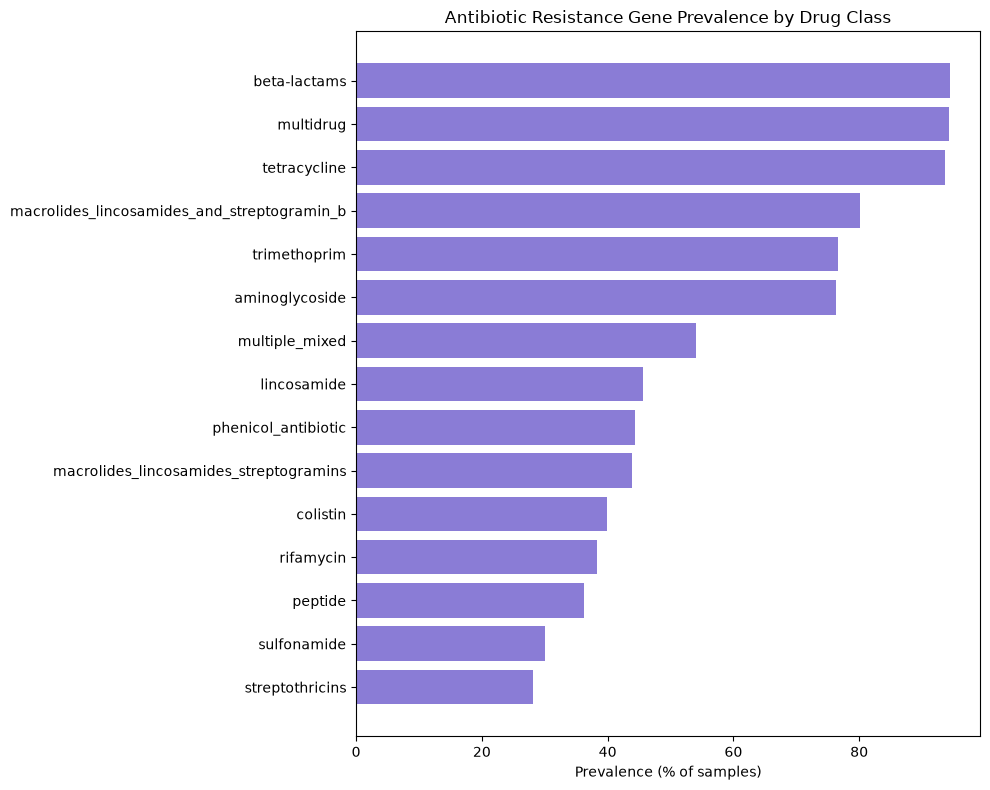

In [35]:
import matplotlib.pyplot as plt

# PROPERLY-GROUPED VISUALISATION

# DRUG-CLASS PREVALENCE
top15_drugclass = drugclass_prevalence.head(15)

plt.figure(figsize=(10, 8))
plt.barh(top15_drugclass.index, top15_drugclass.values, color='#8A7CD6')
plt.xlabel('Prevalence (% of samples)')
plt.title('Antibiotic Resistance Gene Prevalence by Drug Class')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../figures/drugclass_prevalence.png', dpi=300)
plt.show()

In [36]:
# MECHANISM PREVALENCE - calculation and plot
mechanism_cols = [c for c in data3.columns if c.startswith('mechanism_')]

mechanism_prevalence = (data3[mechanism_cols] > 0).mean().sort_values(ascending=False) * 100
mechanism_prevalence.index = mechanism_prevalence.index.str.replace('mechanism_', '')

print(mechanism_prevalence)

antibiotic_inactivation           97.713394
antibiotic_target_protection      96.865246
antibiotic_efflux                 94.354729
antibiotic_target_alteration      93.825485
antibiotic_target_replacement     80.472249
multiple_mechanisms               54.071109
antibiotic_efflux_(regulatory)    28.837020
reduced_permeability              12.654363
dtype: float64


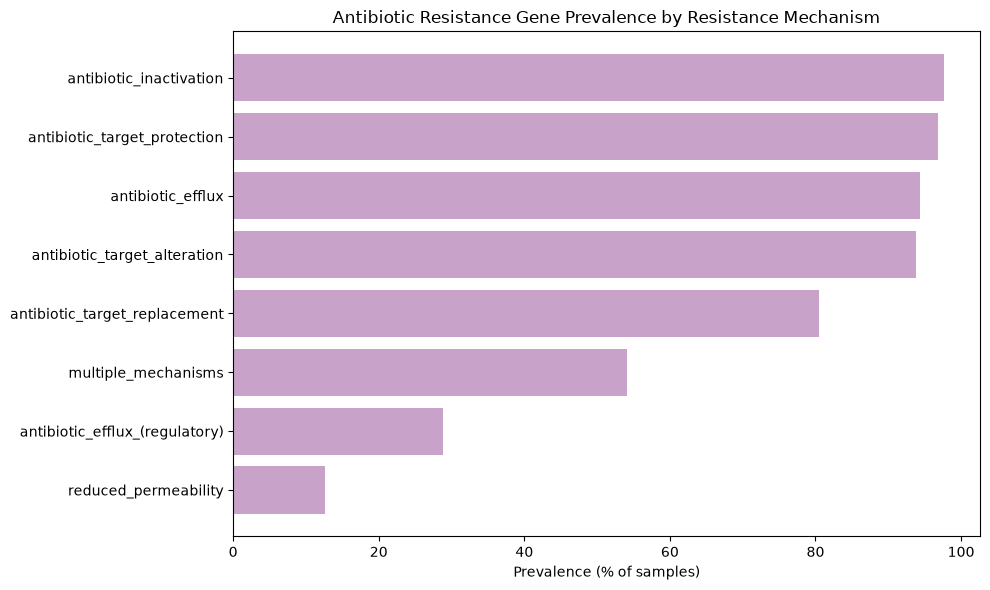

In [37]:
plt.figure(figsize=(10, 6))
plt.barh(mechanism_prevalence.index, mechanism_prevalence.values, color="#C8A2C8")
plt.xlabel('Prevalence (% of samples)')
plt.title('Antibiotic Resistance Gene Prevalence by Resistance Mechanism')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../figures/mechanism_prevalence.png', dpi=300)
plt.show()

Interpretation:

Grouping genes by drug class and resistance mechanism results in two complementary views of the same underlying biology. While resistance to beta-lactams, tetracyclines, and broad multidrug efflux dominates (all upwards of 90% sample prevalence), resistance to more specialised or reserved antibiotic classes (quinolones, fusidic acid, glycopeptides) are far less common. By mechanism, antibiotic inactivation (enzymatic breakdown, e.g. beta-lactamases) and target protection/alteration are the most prevalent strategies (93-98%), while reduced permeability is comparatively rare (12.7%), likely because permeability changes alone are a weaker, supplementary resistance strategy rather than one bacteria rely on independently.

In [38]:
## 10. SHANNON DIVERSITY PER SAMPLE

import numpy as np

# Shannon Diversity - distribution of gene diversity across samples

def shannon_diversity(row, gene_cols):
    """Shannon diversity index based on presence/absence of genes in one sample."""
    values = row[gene_cols].values.astype(float)  # forcing values into proper numeric type, required for calculation
    total = values.sum()
    if total == 0:
        return 0
    proportions = values[values > 0] / total
    return -np.sum(proportions * np.log(proportions))

data3['shannon_diversity'] = data3.apply(lambda row: shannon_diversity(row, gene_columns), axis=1)

print(data3['shannon_diversity'].describe())

C:\Users\Amulya Pinto\AppData\Local\Temp\ipykernel_26620\3844875753.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data3['shannon_diversity'] = data3.apply(lambda row: shannon_diversity(row, gene_columns), axis=1)


count    14738.000000
mean         2.515765
std          0.592142
min         -0.000000
25%          2.197225
50%          2.564949
75%          2.944439
max          3.784190
Name: shannon_diversity, dtype: float64


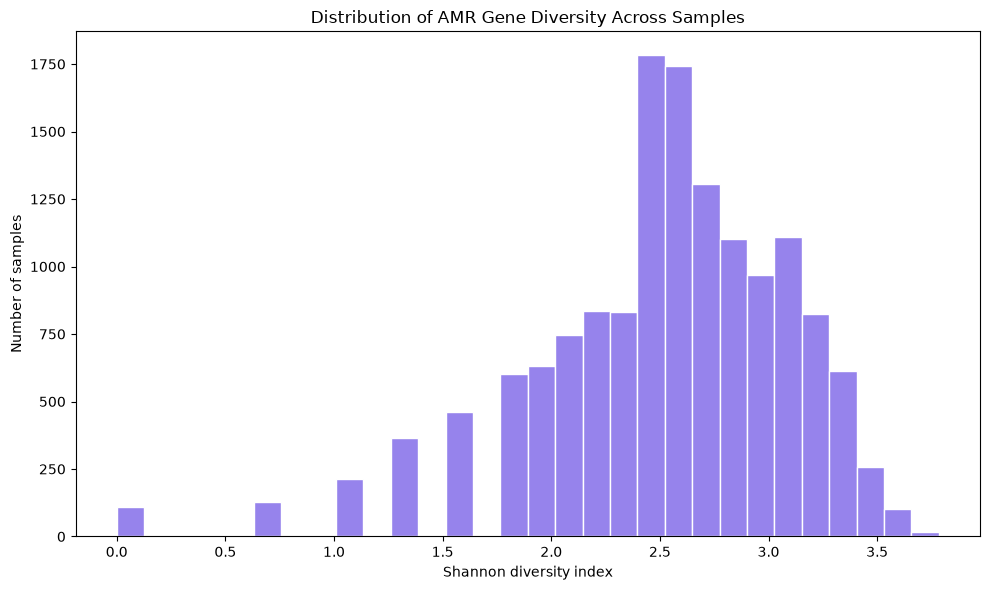

In [39]:
# Diversity distribution plot
plt.figure(figsize=(10,6))
plt.hist(data3['shannon_diversity'], bins=30, color='#9683EC', edgecolor='white')
plt.xlabel('Shannon diversity index')
plt.ylabel('Number of samples')
plt.title('Distribution of AMR Gene Diversity Across Samples')
plt.tight_layout()
plt.savefig('../figures/shannon_diversity_distribution.png', dpi=300)
plt.show()

In [40]:
## 11. INVESTIGATING THE LOW-DIVERSITY CLUSTER

# Isolating the low diversity cluster (the visible gap suggests below ~1.7)
low_diversity = data3[data3['shannon_diversity'] < 1.7]
remaining = data3[data3['shannon_diversity'] >= 1.7]

print(f"Low-diversity samples: {len(low_diversity)} ({len(low_diversity)/len(data3)*100:.1f}% of total)")
print(f"The remaining samples: {len(remaining)}")

Low-diversity samples: 1276 (8.7% of total)
The remaining samples: 13462


In [41]:
print("Body site breakdown - low diversity group:")
print(low_diversity['body_site'].value_counts(normalize=True) * 100)

print("\nBody site breakdown - the remaining samples:")
print(remaining['body_site'].value_counts(normalize=True) * 100)

Body site breakdown - low diversity group:
body_site
stool         80.485893
oralcavity    11.755486
skin           7.758621
Name: proportion, dtype: float64

Body site breakdown - the remaining samples:
body_site
stool         98.068638
skin           1.203387
oralcavity     0.727975
Name: proportion, dtype: float64


In [42]:
# Cross-tab: body site vs diversity group, with proper percentages
data3['diversity_group'] = np.where(data3['shannon_diversity'] < 1.7, 'low_diversity', 'typical diversity')

crosstab = pd.crosstab(data3['body_site'], data3['diversity_group'], normalize='index') * 100
print(crosstab)

C:\Users\Amulya Pinto\AppData\Local\Temp\ipykernel_26620\2620939931.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data3['diversity_group'] = np.where(data3['shannon_diversity'] < 1.7, 'low_diversity', 'typical diversity')


diversity_group  low_diversity  typical diversity
body_site                                        
oralcavity           60.483871          39.516129
skin                 37.931034          62.068966
stool                 7.217654          92.782346


<Figure size 1000x600 with 0 Axes>

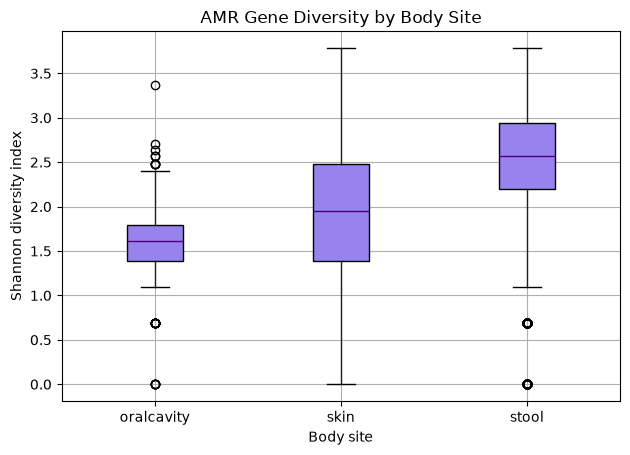

In [43]:
# Boxplot of gene diversity by body site
plt.figure(figsize=(10, 6))
data3.boxplot(column='shannon_diversity', by='body_site',
              patch_artist=True,
              boxprops=dict(facecolor='#9683EC'),
              medianprops=dict(color='#4B0082'))
plt.xlabel('Body site')
plt.ylabel('Shannon diversity index')
plt.title('AMR Gene Diversity by Body Site')
plt.suptitle('')  # removes the default pandas subtitle
plt.tight_layout()
plt.savefig("../figures/diversity_by_bodysite.png", dpi=300, bbox_inches='tight')
plt.show()

Interpretation:

While overall Shannon diversity averaged 2.52 across all samples, this masks a clear and substantial difference by body site. Stool samples exhibit the highest median diversity (~2.6) and the most compact and consistent spread. Oral cavity samples show noticeably lower diversity (median ~1.6) with a much narrower distribution, while skin samples are intermediate on average (median ~1.9) but show the widest variability of any site, ranging almost as broadly as stool and oral cavity combined. 

Quantifying this further: 60.5% of oral cavity samples and 37.9% of skin samples fall into a low-diversity group (Shannon index below 1.7), compared to just 7.2% of stool samples. This is consistent with the well-documented compositional differences between gut, oral, and skin microbiomes, each hosting distinct dominant bacterial taxa, and resistance gene panels (including this dataset's, built on the CARD framework) which tends to be the most comprehensively characterised against gut-associated organisms, since gut microbiome AMR surveillance has historically received the most research attention. An important limitation is that the lower diversity observed at the oral and skin sites may result from a combination of genuine biological differences in the presence of resistance genes and reference database bias towards gut-associated taxa, a distinction that this dataset alone cannot fully disentangle.

In [44]:
## 12. GENE CO-OCCURRENCE HEATMAP

# Getting the top 20 most prevalent genes
top20_genes = gene_prevalence.head(20).index.tolist()

# Computing co-occurrence: correlation between genes based on presence/absence
cooccurrence = data3[top20_genes].corr()

print(cooccurrence.shape)

(20, 20)


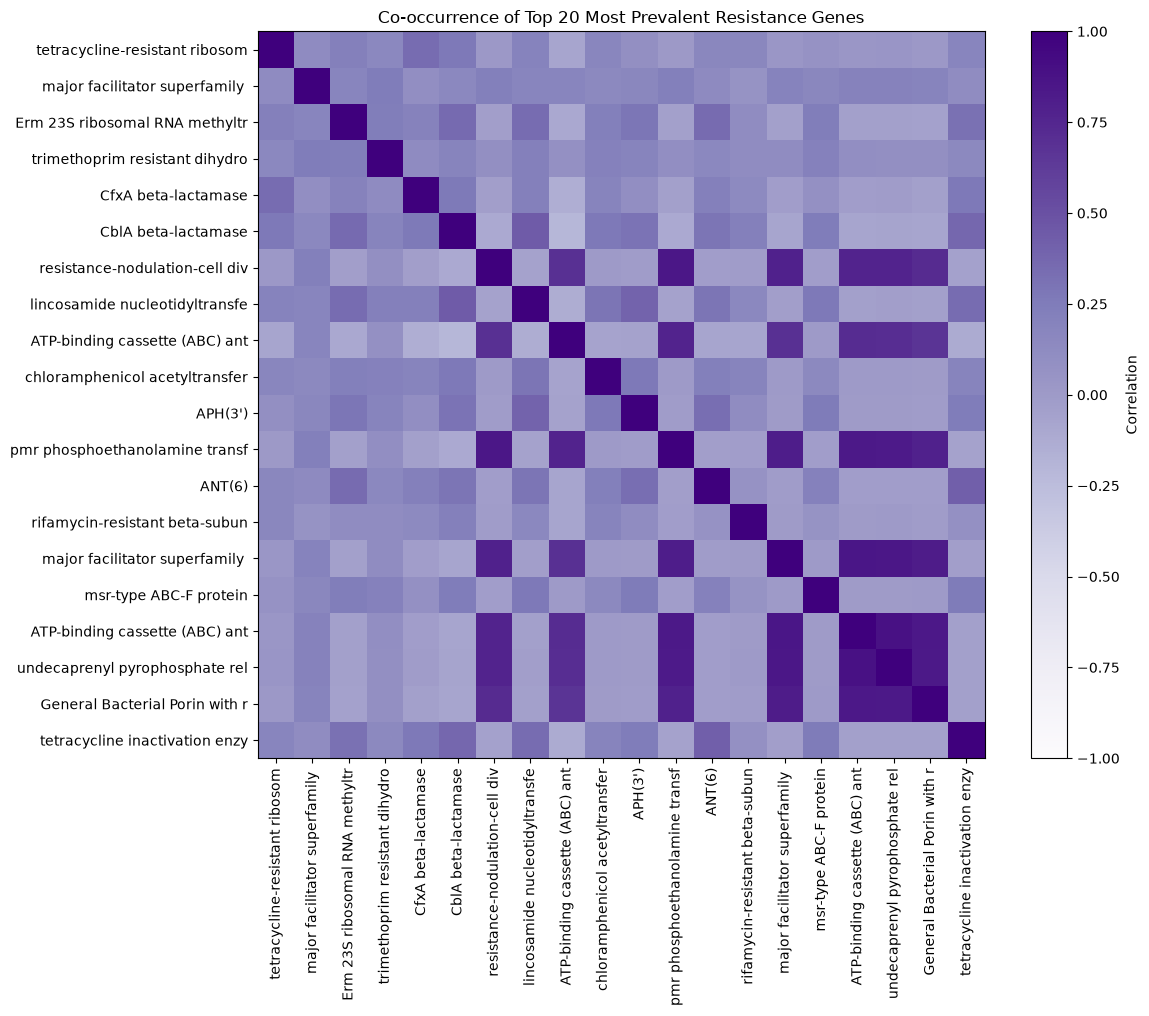

In [45]:
# Heatmap
plt.figure(figsize=(12, 10))
plt.imshow(cooccurrence, cmap='Purples', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')

# Shorten gene names for readability on the axis labels
short_labels = [g[:30] for g in top20_genes]
plt.xticks(range(20), short_labels, rotation=90, ha='center')
plt.yticks(range(20), short_labels)

plt.title('Co-occurrence of Top 20 Most Prevalent Resistance Genes')
plt.tight_layout()
plt.savefig('../figures/gene_cooccurrence_heatmap.png', dpi=300)
plt.show()

Interpretation:

The co-occurrence heatmap of the 20 most prevalent genes reveals a distinct cluster of strongly correlated membrane-associated resistance mechanisms - RND efflux pumps, ABC transporters, phosphoethanolamine transferase, undecaprenyl pyrophosphate-related proteins, and porin-related genes all show elevated positive correlation with one another. This suggests these mechanisms are frequently co-selected, plausibly because they collectively contribute to broader cell-envelope mediated antibiotic defence rather than acting as unrelated, independent adaptations. Most other genes show correlations near zero, indicating that most individual resistance genes harboured in this dataset are largely independent of one another. 

Limitations

This analysis is based on gene presence/absence data alone and does not capture gene expression, copy number, or actual phenotypic resistance (i.e. whether a gene being present translates to clinically measurable resistance in that organism). Additionally, roughly 40% of gene names in the raw dataset lacked pre-existing classification in the provided reference table and were classified using a combination of manual verification against CARD (for ambiguous cases) and keyword-based rules (for names following consistent patterns). While this approach was validated against known genes wherever possible, it introduces some risk of misclassification for edge cases that were not individually checked. The lower diversity observed at the oral cavity and skin sites may also partly reflect reference database detection bias toward gut-associated taxa rather than purely biological differences (see Step 11 - Investigating the low-diversity cluster).